# 07 — Statistical Protocol & Bảng/Hình Final cho Bài Báo

Thực hiện **Section 11** (protocol thống kê Wilcoxon paired theo instance),
**Section 12** (Table 1-4 + 5 hình chính), và tổng hợp gate **Section 13**
để kết luận liệu phân tích đã đủ chuẩn Q1 chưa.

Input: toàn bộ artifacts từ notebook 01-06.
Output: `artifacts/table1_protocol.csv` ... `table4_route_fairness.csv`,
`artifacts/gate_check.json`.


In [1]:
# ==== CẤU HÌNH ĐƯỜNG DẪN (chỉnh lại cho đúng máy của bạn) ====
import sys, os
sys.path.append(os.path.abspath("."))  # để import evrp_analysis_utils.py cùng thư mục

FULL_DIR  = "benchmark/full"     # thư mục kết quả bản đầy đủ (equity-aware)
NOEQ_DIR  = "benchmark/no-EQ"    # thư mục kết quả bản loại equity guidance
ARTIFACT_DIR = "artifacts"       # nơi lưu các bảng trung gian (csv) giữa các notebook
os.makedirs(ARTIFACT_DIR, exist_ok=True)

import pandas as pd
import numpy as np
import evrp_analysis_utils as utils

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)


In [2]:
manifest = pd.read_csv(f"{ARTIFACT_DIR}/run_manifest_matched_valid.csv")
td_solutions = pd.read_csv(f"{ARTIFACT_DIR}/td_solutions.csv")
fleet_attainment = pd.read_csv(f"{ARTIFACT_DIR}/fleet_attainment.csv")
hv2d_results = pd.read_csv(f"{ARTIFACT_DIR}/hv2d_results.csv")
fairness_path = f"{ARTIFACT_DIR}/route_fairness_metrics.csv"
route_fairness = pd.read_csv(fairness_path) if os.path.exists(fairness_path) else pd.DataFrame()


## 7.1. Table 1 — Experimental protocol and audit

In [3]:
table1 = pd.DataFrame({
    "Metric": ["NumInstances", "NumSeedsPerInstance(target)", "MeanIterations", "MeanRuntime_s(FULL)",
               "MeanRuntime_s(No-EQ)", "MeanFleetAttainmentSR(FULL)", "MeanFleetAttainmentSR(No-EQ)"],
    "Value": [
        manifest["Instance"].nunique(),
        10,
        manifest["Iterations"].mean(),
        manifest.loc[manifest["Variant"] == "FULL", "Runtime_s"].mean(),
        manifest.loc[manifest["Variant"] == "No-EQ", "Runtime_s"].mean(),
        fleet_attainment.loc[fleet_attainment["Variant"] == "FULL", "SR"].mean(),
        fleet_attainment.loc[fleet_attainment["Variant"] == "No-EQ", "SR"].mean(),
    ],
})
table1.to_csv(f"{ARTIFACT_DIR}/table1_protocol.csv", index=False)
table1


,Metric,Value
0,NumInstances,92.000000
1,NumSeedsPerInstance(target),10.000000
2,MeanIterations,25000.000000
3,MeanRuntime_s(FULL),364.936689
4,MeanRuntime_s(No-EQ),317.230379
5,MeanFleetAttainmentSR(FULL),0.963736
6,MeanFleetAttainmentSR(No-EQ),0.965934


## 7.2. Table 3 — Controlled Full vs No-EQ ablation (Wilcoxon paired theo instance)

Đơn vị thống kê là **instance**: lấy median qua 10 seed trước khi paired-test
(ở đây TD solution đã gộp toàn bộ seed trong notebook 02; nếu muốn median-qua-seed
thay vì gộp-rồi-lấy-best, điều chỉnh notebook 02 cho phù hợp thiết kế thống kê bạn chọn).

In [4]:
pivot = td_solutions.pivot_table(index="Instance", columns="Variant",
                                  values=[c for c in ["Z2", "Z3", "Z4"] if c in td_solutions.columns])

hv_pivot = hv2d_results.pivot_table(index="Instance", columns="Variant", values="HV2D")

metrics_to_test = {}
for z in ["Z2", "Z3", "Z4"]:
    if (z, "FULL") in pivot.columns and (z, "No-EQ") in pivot.columns:
        metrics_to_test[f"TD_{z}"] = (pivot[(z, "FULL")], pivot[(z, "No-EQ")])
if "FULL" in hv_pivot.columns and "No-EQ" in hv_pivot.columns:
    metrics_to_test["HV2D"] = (hv_pivot["FULL"], hv_pivot["No-EQ"])

results = {}
pvals = {}
for name, (a, b) in metrics_to_test.items():
    common_idx = a.dropna().index.intersection(b.dropna().index)
    res = utils.paired_wilcoxon_report(a.loc[common_idx], b.loc[common_idx])
    results[name] = res
    pvals[name] = res["p"]

pvals_holm = utils.holm_correction(pvals)

table3_rows = []
for name, res in results.items():
    table3_rows.append({
        "Metric": name, "n": res["n"],
        "MedianDiff_FULL_minus_NoEQ": res["hodges_lehmann"],
        "CI95_low": res["ci95_low"], "CI95_high": res["ci95_high"],
        "p_holm": pvals_holm[name], "rank_biserial": res["rank_biserial"],
    })
table3 = pd.DataFrame(table3_rows)
table3.to_csv(f"{ARTIFACT_DIR}/table3_ablation.csv", index=False)
table3


,Metric,n,MedianDiff_FULL_minus_NoEQ,CI95_low,CI95_high,p_holm,rank_biserial
0,TD_Z2,91,1.10260,1.198892,4.196990,1.691826e-03,0.498629
1,TD_Z3,91,-0.00485,-0.014602,-0.005046,1.453821e-04,-0.571848
2,TD_Z4,91,0.00000,-3.089659,2.879850,4.511075e-01,0.168091
3,HV2D,91,0.30779,0.277119,0.385791,1.070560e-13,0.981441


## 7.3. Table 4 — Route-level fairness robustness

In [5]:
if not route_fairness.empty:
    table4 = route_fairness.groupby("Variant")[["Gini", "rho_max", "CV", "Jain", "A_sum", "W_sum"]].agg(["mean", "median"])
    table4.to_csv(f"{ARTIFACT_DIR}/table4_route_fairness.csv")
    table4
else:
    print("Chạy notebook 04 trước để có route_fairness_metrics.csv")


## 7.4. Box/violin plot: paired Gini improvement dưới common fleet + budget (Figure chính #3)

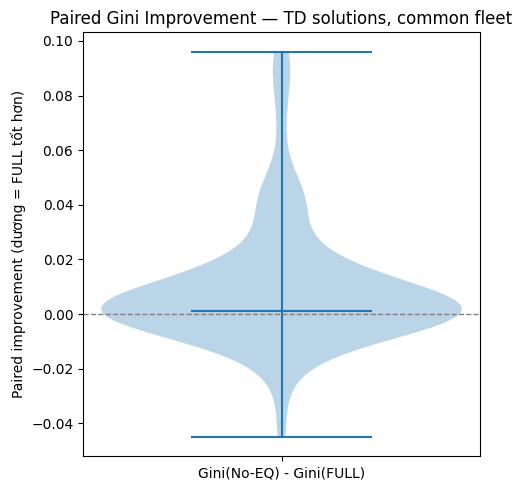

In [6]:
import matplotlib.pyplot as plt

if ("Z3", "FULL") in pivot.columns and ("Z3", "No-EQ") in pivot.columns:
    gini_full = pivot[("Z3", "FULL")]
    gini_noeq = pivot[("Z3", "No-EQ")]
    common_idx = gini_full.dropna().index.intersection(gini_noeq.dropna().index)
    diff = gini_noeq.loc[common_idx] - gini_full.loc[common_idx]  # dương = FULL tốt hơn (Gini thấp hơn)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.violinplot([diff.dropna()], showmedians=True)
    ax.set_xticks([1])
    ax.set_xticklabels(["Gini(No-EQ) - Gini(FULL)"])
    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax.set_ylabel("Paired improvement (dương = FULL tốt hơn)")
    ax.set_title("Paired Gini Improvement — TD solutions, common fleet")
    plt.tight_layout()
    plt.savefig(f"{ARTIFACT_DIR}/fig_paired_gini_improvement.png", dpi=150)
    plt.show()


## 7.5. Distance–Gini Pareto projection, màu theo maxTime (Figure chính #2)

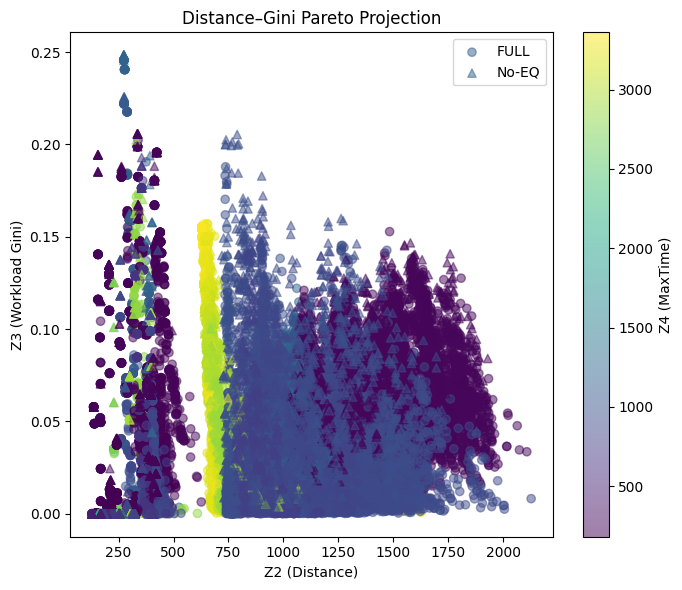

In [7]:
solutions_clean = pd.read_csv(f"{ARTIFACT_DIR}/solutions_clean.csv")
if {"Z2", "Z3"}.issubset(solutions_clean.columns):
    fig, ax = plt.subplots(figsize=(7, 6))
    for variant, marker in [("FULL", "o"), ("No-EQ", "^")]:
        g = solutions_clean[solutions_clean["Variant"] == variant]
        c = g["Z4"] if "Z4" in g.columns else None
        sc = ax.scatter(g["Z2"], g["Z3"], c=c, marker=marker, alpha=0.5, label=variant, cmap="viridis")
    ax.set_xlabel("Z2 (Distance)")
    ax.set_ylabel("Z3 (Workload Gini)")
    ax.set_title("Distance–Gini Pareto Projection")
    if "Z4" in solutions_clean.columns:
        plt.colorbar(sc, label="Z4 (MaxTime)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{ARTIFACT_DIR}/fig_distance_gini_projection.png", dpi=150)
    plt.show()


## 7.6. Gate check (Section 13) — 4 điều kiện để claim Q1

In [8]:
import json

gate = {}

# (1) Fleet attainment of FULL không tệ hơn đáng kể No-EQ
sr_full = fleet_attainment.loc[fleet_attainment["Variant"] == "FULL", "SR"].mean()
sr_noeq = fleet_attainment.loc[fleet_attainment["Variant"] == "No-EQ", "SR"].mean()
gate["fleet_attainment_not_materially_worse"] = bool(sr_full >= sr_noeq - 0.05)

# (2) FULL có Gini thấp hơn có ý nghĩa thống kê (sau Holm)
gini_row = table3[table3["Metric"] == "TD_Z3"]
gate["significantly_lower_constrained_gini"] = bool(
    (not gini_row.empty) and (gini_row["p_holm"].iloc[0] < 0.05) and (gini_row["MedianDiff_FULL_minus_NoEQ"].iloc[0] < 0)
)

# (3) FULL cải thiện ít nhất 2 metric fairness độc lập
if not route_fairness.empty:
    means = route_fairness.groupby("Variant")[["Gini", "rho_max", "CV", "Jain"]].mean()
    improved = 0
    if "FULL" in means.index and "No-EQ" in means.index:
        improved += int(means.loc["FULL", "Gini"] < means.loc["No-EQ", "Gini"])
        improved += int(means.loc["FULL", "rho_max"] < means.loc["No-EQ", "rho_max"])
        improved += int(means.loc["FULL", "CV"] < means.loc["No-EQ", "CV"])
        improved += int(means.loc["FULL", "Jain"] > means.loc["No-EQ", "Jain"])
    gate["at_least_two_independent_fairness_metrics_improved"] = improved >= 2
else:
    gate["at_least_two_independent_fairness_metrics_improved"] = None

# (4) FULL Distance-Focus vẫn cạnh tranh với literature -> cần bảng literature (Section 10), chưa tự động hoá ở đây
gate["distance_focus_competitive_with_literature"] = "CẦN NHẬP THỦ CÔNG (xem notebook literature comparison, Section 10)"

with open(f"{ARTIFACT_DIR}/gate_check.json", "w", encoding="utf-8") as f:
    json.dump(gate, f, ensure_ascii=False, indent=2)

gate


{'fleet_attainment_not_materially_worse': True,
 'significantly_lower_constrained_gini': True,
 'at_least_two_independent_fairness_metrics_improved': True,
 'distance_focus_competitive_with_literature': 'CẦN NHẬP THỦ CÔNG (xem notebook literature comparison, Section 10)'}

## 7.7. Table 2 & literature comparison (Section 10)

Phần này cần bảng benchmark literature (fleet, distance đã công bố cho từng
instance Solomon) mà bạn nhập thủ công hoặc load từ một file riêng, vì đây là
dữ liệu bên ngoài không nằm trong log ALNS. Khung code dưới đây minh hoạ cách
gộp: bạn chỉ cần cung cấp `literature.csv` với cột `Instance, PublishedFleet,
PublishedDistance` (và Source nếu muốn).

In [9]:
lit_path = "literature.csv"  # <-- cung cấp file này nếu có
if os.path.exists(lit_path):
    literature = pd.read_csv(lit_path)
    full_td = td_solutions[td_solutions["Variant"] == "FULL"][["Instance", "Z1", "Z2"]]
    table2 = literature.merge(full_td, on="Instance", how="left").rename(
        columns={"Z1": "FULL_Fleet", "Z2": "FULL_Distance"}
    )
    table2["DistanceGap_pct"] = (table2["FULL_Distance"] / table2["PublishedDistance"] - 1) * 100
    table2.to_csv(f"{ARTIFACT_DIR}/table2_literature_comparison.csv", index=False)
    print(table2.describe())
    table2.head(10)
else:
    print(f"Chưa có {lit_path} — bỏ qua Table 2 cho tới khi có dữ liệu literature.")


Chưa có literature.csv — bỏ qua Table 2 cho tới khi có dữ liệu literature.


## 7.8. Tóm tắt

Toàn bộ artifacts trung gian (`.csv`, `.png`, `.json`) nằm trong thư mục
`artifacts/`. Các bảng `table1_protocol.csv`, `table3_ablation.csv`,
`table4_route_fairness.csv`, và (nếu có) `table2_literature_comparison.csv`
tương ứng chính xác với Table 1–4 trong Section 12 của kế hoạch phân tích.
Các hình `fig_budget_equity_curve.png`, `fig_distance_gini_projection.png`,
`fig_paired_gini_improvement.png` tương ứng Figure 1–3. Figure 4 (route
workload bars) và Figure 5 (convergence) nằm ở notebook 05 và 06.
